# Aula 13


# Modelo de difusão controlada usando o método DDIM


### Eduardo Lobo Lustosa Cabral

## 1. Objetivos

- Apresentar o método de difusão "Denoise Diffusion Implicit Model" (DDIM) aplicado a geração de imagens.

- Usando os conceitos básicos de difusão vistos na aula anterior, vamos usar o método de difusão para gerar novas imagens de forma condicional.


## 2. Introdução

Os [modelos de difusão](https://arxiv.org/abs/2006.11239) ganharam popularidade como sendo um método poderoso de geração de novos dados, melhores do que as GANs para gerar imagens de qualidade (https://arxiv.org/abs/2105.05233 e https://arxiv.org/abs/1406.2661).

Os modelos de difusão tendem a gerar amostras mais diversas, sendo também mais estáveis para treinar e fáceis de escalar.

Modelos recentes de difusão, tais como, [DALL-E 2]((https://openai.com/dall-e-2/)) e [Imagem]((https://imagen.research.google/)), tem uma  capacidade incrível de geração de imagens a partir de texto.

A única desvantagem dos modelos de difusão é que eles são mais lentos para amostrar, porque exigem várias etapas de difusão reversa para gerar uma nova imagem.

Como visto na aula anterior, o processo de difusão consiste em transformar passo-a-passo um sinal estruturado (por exemplo uma imagem) em ruído. Ao simular a difusão, ruído é introduzido nas imagens e uma rede neural é treinada para retirar esse ruído. Usando a rede treinada é possível simular o oposto da difusão (difusão reversa), que consiste na transformação de ruído em uma imagem.

No GIF da Figura 1 é mostrado esse processo.

![diffusion process gif](https://i.imgur.com/dipPOfa.gif)

<center>Figura 1 - Esquema do processo de difusão para criar modelos generativos (https://i.imgur.com/dipPOfa.gif).</center>



Resumindo: **modelos de difusão são treinados para retirar ruído de imagens e são capazes de gerar imagens iterativamente a partir de ruído puro.**

O modelo de difusão implementado nessa aula, consiste no método "Denoising Diffusion Implicit Models" [DDIM]((https://arxiv.org/abs/2010.02502)).


## 3. Denoise Difussion Implicit Model (DDIM)

A maior deficiência do método DDPM é que ele exige muitas iterações para produzir uma amostra de alta qualidade. Isso ocorre porque o processo generativo (do ruído para os dados) é o inverso do processo de difusão para frente (dos dados para o ruído), que pode ter centenas de etapas $\to$ iterar todas as etapas é necessário para produzir uma única amostra, o que é muito lento.

Para resolver esse problema Mohamed & Lakshminarayanan, 2016 criaram o método [DDIM](https://arxiv.org/abs/1610.03483) $\to$ enquanto o DDPM usa, por exemplo, 1000 passos para gerar uma amostra o DDIM utiliza uma quantidade muito menor de passos, cerca de 10 a 100 passos.

O método DDIM é muito similar ao método DDPM, sendo que a rede neural usada tem a mesma função, ou seja, prever o ruído inserido nos dados no instante de tempo $t$, e usa a mesma função de custo.

A qualidade das amostras geradas pelo método DDIM são um pouco inferiores às geradas pelo método DDPM, mas o custo benefício do DDIM é muito melhor.

O modelo DDIM é igual ao método DDPM, somente diferindo da forma como o processo de difusão reversa é implementado.

As principais diferenças do método DDIM em relação ao método DDPM visto na aula anterior são as seguintes:

1. A escala de tempo no DDIM é contínua, enquanto que no DDPM é discreta;
2. Na previsão da amostra no instante de tempo $t-\Delta t$ não é inserido um novo ruído;
3. A reversão no tempo é realizada pulando etapas, ou seja, enquanto o processo de difusão para frente é realizado, por exemplo, usando 1000 passos, no processo de reversão no método DDIM ele é realizado pulando vários instantes de tempo;
4. Usa uma programação cossenoidal para a variância em função do tempo.


### 3.1 Etapa de treinamento do modelo

No método DDIM, o modelo é treinado da mesma forma que no método DDPM, ou seja, para prever a quantidade de ruído inserida na etapa de difusão do instante de tempo $t$.

A função de custo utlizada no DDIM é a mesma do DDPM, ou seja, o erro quadrático médio.

O processo de treinamento do modelo no método DDIM, realizado em cada época de treinamento é o seguinte:
   
1. Amostra uniformemente no intervalo entre 0 e 1, um instante de tempo $t$ para cada dado do lote;

    $$t \leftarrow \ uniforme(0,..., 1)$$
    
    
        
2. Calcula usando uma programação cossenoidal os parâmetros de variância (nível de sinal e nível de ruído) para cada imagem do lote ($\sqrt{\bar \alpha_t}$ e $\sqrt{1 - \bar \alpha_t}$), correspondentes aos instantes de tempo selecionados. Observe que $\sqrt{\bar \alpha_t}$ e $\sqrt{1 - \bar \alpha_t}$, podem ser vistos como seno e cosseno de um ângulo, assim, na programação cossenoidal calcula-se diretamente esses parâmetros na forma do cosseno e seno de um ângulo que varia de 0 a 90 graus;

    
3. Obtém um lote de ruídos gaussiano, com mesma dimensão das imagens, com média igual a zero e variância igual a 1;

    $$\epsilon \leftarrow \ N(0,I)$$
    

4. Insere nível de ruído correspondente aos instantes de tempo $t$ em cada imagem do lote:

   $$x_t = \sqrt{\bar \alpha_t} x_0 + \sqrt{1 - \bar \alpha_t} \epsilon$$  
    
5. Tendo as imagens corrompidas com ruído como entrada, o modelo prevê o ruído inserido em cada imagem do lote;

   $$\hat \epsilon_{\theta}(x_t,t)$$
    
    
6. Calcula o valor da função de custo MSE entre o ruído inserido e o ruído previsto pelo modelo;

    $$ \parallel \epsilon - \hat \epsilon_{\theta} \parallel_2^2$$

7. Atualiza os parâmetros do modelo usando o gradiente da função de custo.
    
Repete as etapas 1 a 7 quantas épocas forem desejadas.

### 3.2 Difusão reversa

Após o treino, o modelo pode ser usado para realizar a operação de difusão reversa e, assim, obter os dados originais a partir de uma amostra de ruído.

O processo de difusão reversa é realizado da seguinte forma:

I. Amostra um tensor de ruído de mesma dimensão das imagens com distribuição Gaussiana de média 0 e desvio padrão 1, isso representa a imagem com ruído no instante de tempo $T=1$ (tempo final do processo);

   $$\epsilon \leftarrow \ N(0,I)$$
    
II. Percorre um ciclo com $N$ passos, variando o tempo de $t=1$ até $t=0$, calculando as etapas de difusão reversa, onde é realizado:

1. Calcula o instante de tempo: $t = 1 - \frac{n}{N}$, onde $n$ é o número de passos que varia de $1$ a $N$.


2. Dado o instante de tempo $t$ calcula, usando a programação cossenoidal, os parâmetros de variância ($\sqrt{\bar \alpha_t}$ e $\sqrt{1 - \bar \alpha_t}$), ou seja $cos(\theta(t))$ e $sin(\theta(t))$.


3. Usando o modelo treinado, calcula uma previsão para o tensor do ruído inserido no instante de tempo corrente;
    
$$\hat \epsilon_{\theta}(x_t, t)$$


4. Calcula a previsão para as imagens sem ruído, ou seja, as imagens no instante de tempo $t=0$:

   $$x_0 = \frac{x_t - \sqrt{1 - \bar \alpha_t} \hat \epsilon_{\theta}}{\sqrt{\bar \alpha_t}}$$


5. Calcula instante de tempo anterior $t-\Delta t$ usando $t -\Delta t = 1 - \frac{2n}{N}$;


6. Calcula, usando a programação cossenoidal, os parâmetros de variância no instante de tempo $t-\Delta t$, ou seja, $\sqrt{\bar \alpha_{t-\Delta t}}$ e $\sqrt{1 - \bar \alpha_{t-\Delta t}}$.   


7. Remove o ruído e recupera as imagens no instante de tempo anterior ($t-\Delta t$);

   $$x_{t-\Delta t} = \sqrt{\bar \alpha_{t-\Delta t}} x_0 + \sqrt{1 - \bar \alpha_{t-\Delta t}} \hat \epsilon_{\theta}$$
    
Após os $N$ passos a amostra sem ruído é gerada.

Observa-se que no cálculo da imagem usada no instante de instante de tempo anterior ($x_{t-\Delta t}$) não se insere novamente um ruído como no método DDPM.

## Importação das principais bibliotecas

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

## Dados

Vamos usar o conjunto de dados MNIST como exemplo de funcionamento de um modelo de difusão DDIM. O MNIST consiste de cerca de 60.000 imagens dos 10 dígitos.

As imagens são em tons de cinza e foram redimensionadas para terem dimensão de 32x32 pixels.

Os dados são divididos em conjunto de treinamento, com 60.000 exemplos, e conjunto de teste com 10.000 exemplos

Esse conjunto de dados está disponível no módulo Dataset do Pytorch, sendo, portanto, fácil de carregar.

Vamos usar somente as imagens do conjunto de treinamento.

### Pré-processamento dos dados

Para preparar as imagens vamos normalizá-las para que os pixels tenham valores reais entre -1 e 1. Nos modelos de difusão essa normalização é obrigatória porque o ruído inserido tem media zero e desvio padrão igual a 1.


In [ ]:
# Define pré-processamento
transformacoes = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Cria gerador de dados
dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transformacoes,
    download=True
)

# Define tamanho do lote
batch_size = 100

# Cria pipeline de dados
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 65.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.71MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.0MB/s]


In [ ]:
total_exemplos = len(dataset)
print(f"Número total de exemplos no dataset: {total_exemplos}")

x, y = next(iter(loader))
print(f"Dimensãoe do lote de imagens (x): {x.shape}")
print(f"Dimensão do lote de classes (y): {y.shape}")

print('Valores mínimo e máximo das imagens:', torch.min(x), torch.max(x))

Número total de exemplos no dataset: 60000
Dimensãoe do lote de imagens (x): torch.Size([100, 1, 32, 32])
Dimensão do lote de classes (y): torch.Size([100])
Valores mínimo e máximo das imagens: tensor(-1.) tensor(1.)


Teste do pré-processamento dos dados.

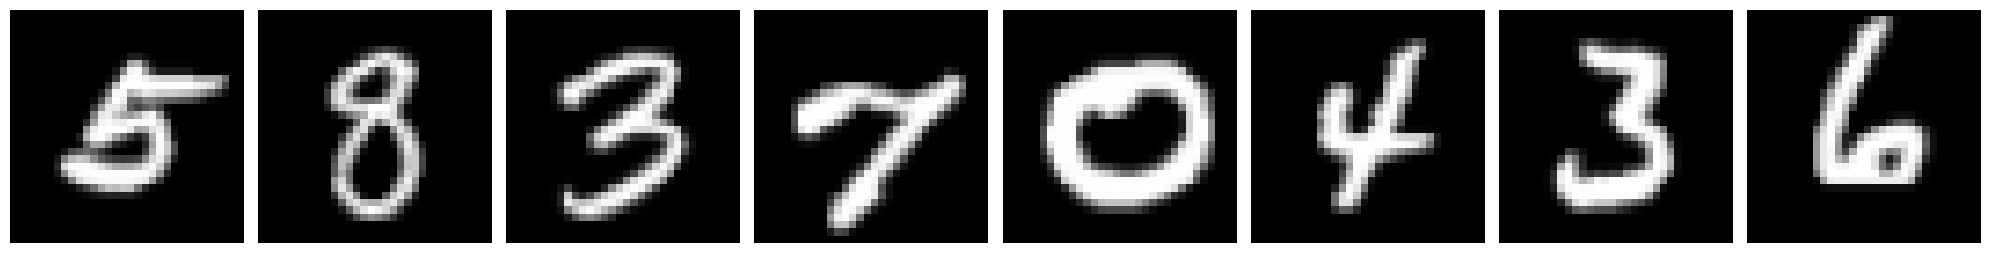

In [ ]:
def plot_images(images, filename="resultado_difusao.png"):
    """
    Exibe 8 imagens em uma única linha.
    images: Tensor de forma (8, C, H, W) e não (8, H, W, C)
    """
    # Garantir que o tensor está na CPU e em formato numpy
    if torch.is_tensor(images):
        images = images.detach().cpu()
        # Se o formato for (B, C, H, W), mudar para (B, H, W, C)
        if images.shape[1] == 1 or images.shape[1] == 3:
            images = images.permute(0, 2, 3, 1)

    # Criar subplots: 1 linha e 8 colunas
    fig, axes = plt.subplots(1, 8, figsize=(20, 3))

    for i in range(8):
        img = images[i].numpy()*0.5 + 0.5

        # Normalização simples caso os pixels estejam fora do intervalo [0, 1]
        if img.min() < 0 or img.max() > 1:
            img = (img - img.min()) / (img.max() - img.min())

        # Plotar imagem (tons de cinza se tiver apenas 1 canal)
        if img.shape[-1] == 1:
            axes[i].imshow(img.squeeze(), cmap='gray')
        else:
            axes[i].imshow(img)

        axes[i].axis('off') # Remove os eixos para limpeza visual

    plt.tight_layout()
    plt.savefig(filename) # Salva a imagem no diretório atual

plot_images(x, "epoca_0.png")

## 3. Rede neural

O modelo usa a rede [U-Net](https://arxiv.org/abs/1505.04597) com entrada e saída de mesmas dimensões. Na Figura 1 é apresentada o esquema da rede U-Net.


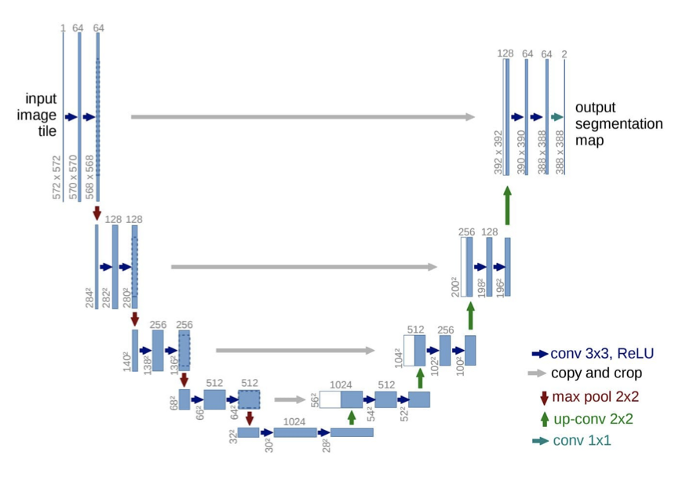
<center>Figura 1 - Esquema da rede U-Net (https://arxiv.org/abs/1505.04597).("Unet.png")</center>

### 3.1 Características da rede

A rede neural usada é igual ao modelo da aula anterior, mas tanto nos blocos do codificador e do decodificador são inseridas as codificações das classes e dos instantes de tempo de difusão.

Somente para lembrar, algumas caraterísticas da rede:

1. As camadas da rede são blocos residuais.


2. São usados modelos do Pytorch para criar os blocos residuais da rede.


3. Os instantes de tempo e as classes são codificados por camadas embedding presentes em cada bloco de convolução.


4. No lugar de camadas de BatchNormalization são usdas camadas de GroupNormalization, que realizada a normalização para grupos de canais no lugar de uma única normalização para todos os canais.


5. Os parâmetros da última camada convolucional são inicializados com zeros $\to$ observe que em princípio, durante o processamento as imagens consistem de ruídos com média zero e desvio padrão igual a 1, portanto, a média das previsões são de fato iguais a zero. Além disso, isso melhora o desempenho da rede no início do treinamento e faz com que o erro quadrático inicial seja extamente igual a 1.


Nesse caso, a rede recebe três entradas:

1. Imagem com ruído no instante de tempo $t$;
2. Instante de tempo de difusão $t$.
3. Classe da imagem codificada one_hot.

A saída da rede é a previsão do erro presente na imagem no instante de tempo $t$.


Em um modelo gerativo de imagens a condição (classe) e o instante de tempo e a classe no modelo são incorporados no modelo da seguinte forma:

1. A classe das imagens é incluída no modelo com uma camada embeding, que usa uma camada tipo densa;


2. A variância é incluída no modelo com uma codificação cossenoidal;


3. A classe e o instante de tempo codificados são incorporados aos dados em cada etapa do codificador (redução da altura/largura) e em cada etapa do decodificador (aumento da altura/largura). A classe e o tempo de difusão são incorporados aos dados da seguinte forma:

$$x = a + c_{emb} + t_{emb}$$

onde $x$ é a entrada da próxima "camada", $a$ é a ativação da camada "anterior", $c_{emb}$ é a codificação embedding das classes e
 $t_{emb}$ é a codificação embedding dos instantes de tempo.

Observa-se que existem diversas outras formas de incorporar as classes e os instantes de tempo no modelo, por exemplo, no lugar de usar operações de multiplicação e soma, usa-se concatenação.

Na Figura 2 é mostrado um esquema de como é feita essa incorporação.

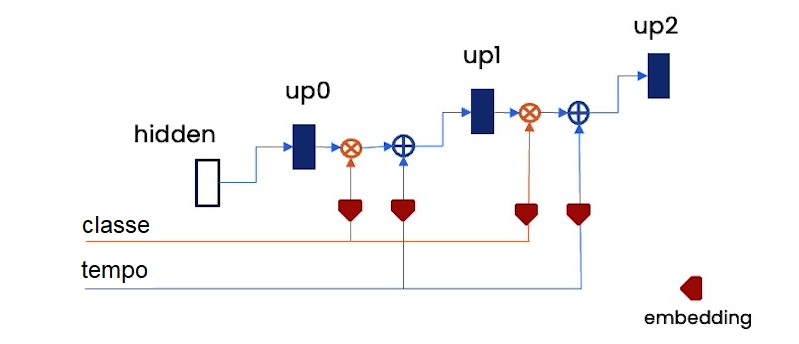

<center>Figura 2 - Forma de incoporar a classe e o instante de tempo na rede neural do modelo de difusão. ("Incorporacao_classe_tempo.jpg").</center>

### 3.2 Codificação embedding das classes e do tempo

Nesse modelo as classes e os tempos são codificadas usando uma camada densa.

A classe `ClassEmbedding` realiza a codificação da classe e a `TimeEmbedding` a codificação dos tempos.


In [ ]:
class ClassEmbedding(nn.Module):
    def __init__(self, n_class, dim):
        super().__init__()
        self.emb = nn.Embedding(n_class, dim)

    def forward(self, y):
        return self.emb(y)

class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.lin = nn.Linear(1, dim)

    def forward(self, t):
        return self.lin(t.unsqueeze(-1).float())

### 3.3 Programação da vairância

O Método DDIM utiliza uma programação cossenoidal para a variância de acordo com o implementado na função a seguir.

No Pytorch, se quisermos usar GPU, temos que mover o modelo e os dados para a GPU.

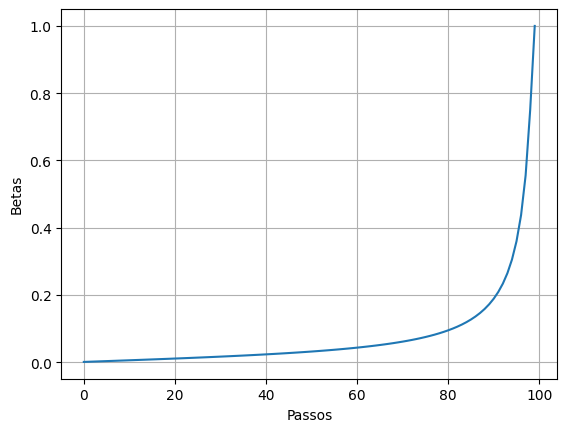

In [ ]:
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Programação cossenoidal da variância (beta)
def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

# Exemplo de programação da variãncia
betas = cosine_beta_schedule(100).to(device)

# Gráfico
plt.plot(betas.to("cpu"))
plt.xlabel('Passos')
plt.ylabel('Betas')
plt.grid()
plt.show()

### 3.4 Blocos residuais

Em modelos de difusão de alto desempenho (como os que utilizam a arquitetura original da Ho et al. ou Stable Diffusion), a condição (seja ela texto ou classe) é injetada em todos os blocos da U-Net, e não apenas no início.

Isso é fundamental porque:

- Preserva a intenção: conforme a imagem passa pelo pooling (redução), a informação da classe pode se "diluir". Reinjetá-la garante que a rede lembre o que deve gerar em diferentes escalas espaciais.

- Fornece um guia em múltiplas resoluções: as camadas iniciais cuidam de formas globais (ex: a silhueta de um gato), enquanto as finais cuidam de texturas (ex: os pelos). A classe influencia ambos.

Os blocos residuais são usados no Encoder, Bottleneck e Decode. A codificação embedding das classes e do tempo são passados e somados em todos os níveis.

In [ ]:
class ResnetBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.relu = nn.SiLU()

        # Projeção do embedding específica para este bloco
        self.emb_proj = nn.Linear(emb_dim, out_ch)

    def forward(self, x, emb):
        h = self.conv1(x)
        h = self.norm1(h)
        # Injeta o embedding após a normalização
        h = h + self.emb_proj(emb).unsqueeze(-1).unsqueeze(-1)
        h = self.relu(h)
        h = self.conv2(h)
        h = self.norm2(h)
        return self.relu(h + x if x.shape == h.shape else h)

### 3.5 Rede completa

A rede completa é configurada na classe `ResNetUnet`.

Para criar uma instância dessa classe são necessários os seguintes argumentos:

1. Número de classes presentes nos dados: `n_class`;
2. Dimensão dos embeddings.

A rede recebe três entradas (imagem com ruído, instante de tempo e a classe da imagem) e retorna o ruído inserido na imagem pixel-a-pixel.


In [ ]:
class ResNetUNet(nn.Module):
    def __init__(self, n_class, emb_dim=128):
        super().__init__()
        self.time_emb = TimeEmbedding(emb_dim)
        self.class_emb = ClassEmbedding(n_class, emb_dim)

        # Entrada inicial
        self.inc = nn.Conv2d(1, 64, kernel_size=3, padding=1)

        # ENCODER
        self.down1 = ResnetBlock(64, 128, emb_dim)
        self.down2 = ResnetBlock(128, 256, emb_dim)
        self.pool = nn.MaxPool2d(2)

        # Gargalo
        self.bottleneck = ResnetBlock(256, 256, emb_dim)

        # DECODER
        self.up2 = nn.ConvTranspose2d(256, 256, kernel_size=2, stride=2)
        self.conv_up2 = ResnetBlock(256 + 256, 128, emb_dim) # Concatena: 256 (up) + 256 (skip)

        self.up1 = nn.ConvTranspose2d(128, 128, kernel_size=2, stride=2)
        self.conv_up1 = ResnetBlock(128 + 128, 64, emb_dim) # Concatena: 128 (up) + 128 (skip)

        # Saída final
        self.outc = nn.Conv2d(64, 1, kernel_size=3, padding=1)

    def forward(self, x, t, y):
        # Obter embeddings do tempo e classe
        t_emb = self.time_emb(t)
        y_emb = self.class_emb(y)
        emb = t_emb + y_emb

        # Primeira camada convolucional
        x1 = self.inc(x) # [Batch, 64, 32, 32]

        # Encoder
        d1 = self.down1(x1, emb) # [Batch, 128, 32, 32]
        p1 = self.pool(d1)        # [Batch, 128, 16, 16]

        d2 = self.down2(p1, emb) # [Batch, 256, 16, 16]
        p2 = self.pool(d2)        # [Batch, 256, 8, 8]

        # Gargalo
        b = self.bottleneck(p2, emb) # [Batch, 256, 8, 8]

        # Decoder
        u2 = self.up2(b)             # [Batch, 256, 16, 16]
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv_up2(u2, emb)

        u1 = self.up1(u2)             # [Batch, 128, 32, 32]
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv_up1(u1, emb)

        # Previsão do erro
        e_pred = self.outc(u1)

        return e_pred

- Profundidade: devemos adicionar canais crescentes (por exemplo, 32 -> 64 -> 128), o que permite ao modelo aprender representações mais complexas, essenciais para modelos de difusão de imagens.

- Flexibilidade: o condicionamento (soma do emb) é feito em todos os bloco residuais após a entrada, garantindo que o tempo e a classe guiem todo o processo de reconstrução desde o início.

- O PyTorch utiliza uma funcionalidade chamada Broadcasting. Como o emb tem a forma (Batch, units, 1, 1) e os mapas de características têm formas como (Batch, units, H, W), ao fazer x + emb, o PyTorch "estica" o vetor de embedding para todas as posições espaciais ($H, W$). Assim, cada pixel da imagem recebe a informação do tempo e da classe antes de passar pela próxima convolução.

- É utilizado GroupNormalization em vez de BatchNormalization: em modelos de difusão, as estatísticas de batch mudam drasticamente dependendo do nível de ruído ($t$). A camada GroupNormalization não depende do tamanho do lote, sendo muito mais estável.

- Função de ativação SiLU: a função de ativação SiLU ($x \cdot \sigma(x)$) é suave e evita o problema de "neurônios mortos" da ReLU, sendo o padrão em modelos de difusão.

Vamos configurar e testar um modelo com os seguintes números de canais: `units = [32, 64, 128]`





In [ ]:
# Configura modelo
model = ResNetUNet(10)
print(model)

ResNetUNet(
  (time_emb): TimeEmbedding(
    (lin): Linear(in_features=1, out_features=128, bias=True)
  )
  (class_emb): ClassEmbedding(
    (emb): Embedding(10, 128)
  )
  (inc): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down1): ResnetBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
    (relu): SiLU()
    (emb_proj): Linear(in_features=128, out_features=128, bias=True)
  )
  (down2): ResnetBlock(
    (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 256, eps=1e-05, affine=True)
    (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 256, eps=1e-05, affine=True)
    (relu): SiLU()
    (emb_proj): Linear(in_features=128, out_features

Para obter o sumário do modelo temos que usar o módulo trochinfo.

In [ ]:
!pip install torchinfo

Para usar o torchinfo temos que executar o modelo com um lote de dados.

In [ ]:
from torchinfo import summary

# Define dimensões
input_size_x = (batch_size, 1, 32, 32) # Imagem
input_size_t = (batch_size,)           # Tempo
input_size_y = (batch_size,)           # Classe

# Gerando o resumo
summary(model.to(device), input_data=[torch.randn(input_size_x).to(device),
                           torch.randn(input_size_t).to(device),
                           torch.randint(0, 10, input_size_y).to(device)])

Layer (type:depth-idx)                   Output Shape              Param #
ResNetUNet                               [100, 1, 32, 32]          --
├─TimeEmbedding: 1-1                     [100, 128]                --
│    └─Linear: 2-1                       [100, 128]                256
├─ClassEmbedding: 1-2                    [100, 128]                --
│    └─Embedding: 2-2                    [100, 128]                1,280
├─Conv2d: 1-3                            [100, 64, 32, 32]         640
├─ResnetBlock: 1-4                       [100, 128, 32, 32]        --
│    └─Conv2d: 2-3                       [100, 128, 32, 32]        73,856
│    └─GroupNorm: 2-4                    [100, 128, 32, 32]        256
│    └─Linear: 2-5                       [100, 128]                16,512
│    └─SiLU: 2-6                         [100, 128, 32, 32]        --
│    └─Conv2d: 2-7                       [100, 128, 32, 32]        147,584
│    └─GroupNorm: 2-8                    [100, 128, 32, 32]       

## 4. Treinamento do modelo

O treinamento do modelo é realizado por um processo customizado.

No Pytorch, se quisermos usar GPU, temos que mover o modelo e os dados para a GPU.

In [ ]:
# Mover o modelo para a GPU
model = ResNetUNet(10).to(device)

# Cria otimizador
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Número de iterações
T = 100

# Calcula as variâncias em função do tempo
betas = cosine_beta_schedule(T).to(device)

# Calcula os alfas e alfa_bar
alphas = 1 - betas
alpha_bar = torch.cumprod(alphas, dim=0).to(device)

# Lista de losses por época
loss_list = []

# Boa prática: garantir que o modelo está em modo de treino
model.train()

# Número de épocas
num_epochs = 20

for epoch in range(num_epochs):
    start = time.time()

    print('Treinando época:', epoch)

    steps = 0
    loss_batch = []
    for x, y in loader:
        # Mover dados de entrada (x) e labels (y) para a GPU
        x = x.to(device)
        y = y.to(device)

        # Criar t diretamente na GPU
        t = torch.randint(0, T, (x.size(0),), device=device)

        # Imagem de ruído já será criada no mesmo device de x
        noise = torch.randn_like(x)

        # As operações abaixo ocorrerão na GPU pois alpha_bar e t estão lá
        sqrt_alpha_bar = torch.sqrt(alpha_bar[t]).view(-1,1,1,1)
        sqrt_one_minus = torch.sqrt(1-alpha_bar[t]).view(-1,1,1,1)

        xt = sqrt_alpha_bar * x + sqrt_one_minus * noise

        # O input t é normalizado e enviado ao modelo
        pred = model(xt, t.float()/T, y)

        loss = ((noise - pred)**2).mean()

        loss_batch.append(loss)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if steps % 100 == 0:
            print('    Step=', steps, 'Loss=', loss.item())
        steps += 1

    # Correctly calculate the mean of loss_batch by stacking the tensors
    loss_epoch = torch.mean(torch.stack(loss_batch)).item()
    loss_list.append(loss_epoch)

    gpu_time = time.time() - start
    print("    Resultado final:  ", 'Tempo GPU=:', gpu_time, "  Loss=", loss_epoch)

Treinando época: 0
    Step= 0 Loss= 1.0676324367523193
    Step= 100 Loss= 0.061288945376873016
    Step= 200 Loss= 0.047781962901353836
    Step= 300 Loss= 0.04052160307765007
    Step= 400 Loss= 0.044501736760139465
    Step= 500 Loss= 0.04141104221343994
    Resultado final:   Tempo GPU=: 70.67917609214783   Loss= 0.060509320348501205
Treinando época: 1
    Step= 0 Loss= 0.041828833520412445
    Step= 100 Loss= 0.04055420309305191
    Step= 200 Loss= 0.03652756288647652
    Step= 300 Loss= 0.03520359843969345
    Step= 400 Loss= 0.03674154728651047
    Step= 500 Loss= 0.03260063752532005
    Resultado final:   Tempo GPU=: 75.67269134521484   Loss= 0.03836451470851898
Treinando época: 2
    Step= 0 Loss= 0.03857044503092766
    Step= 100 Loss= 0.03275861591100693
    Step= 200 Loss= 0.029925385490059853
    Step= 300 Loss= 0.029961833730340004
    Step= 400 Loss= 0.030711611732840538
    Step= 500 Loss= 0.029979821294546127
    Resultado final:   Tempo GPU=: 75.20895648002625   Loss

### 4.1 Resultado do processo de treinamento

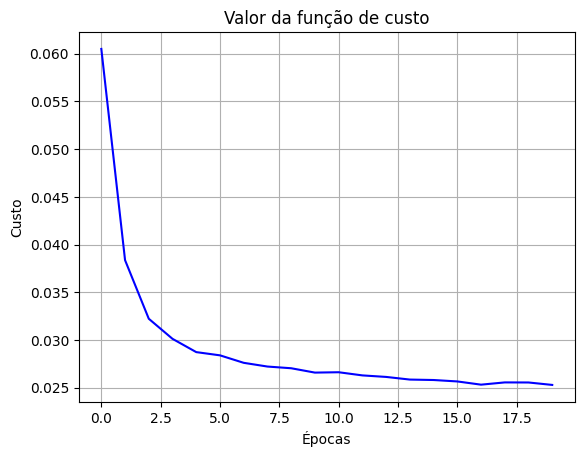

In [ ]:
plt.plot(loss_list, 'b')
plt.title('Valor da função de custo')
plt.xlabel('Épocas')
plt.ylabel('Custo')
plt.grid()
plt.show()

## 5. Uso do modelo

Para usar o modelo para gerar novas imagens, vamos criar uma função que aplica o processo de difusão inversa.

In [ ]:
@torch.no_grad()
def ddim_sample(model, label, steps=50):
    model.eval()
    device = next(model.parameters()).device

    # Inicia com ruído de distribuição normal com dimensão igual à da imagem
    x = torch.randn(1, 1, 32, 32).to(device)

    # Cria a sequência de passos (de T-1 até 0)
    # Usa steps+1 para garantir que as janelas entre os passos cubram todo o intervalo
    times = torch.linspace(T - 1, 0, steps + 1).long().to(device)

    for i in range(steps):
        t = times[i]
        t_prev = times[i+1]

        # Labels e tempo normalizado
        lbl = torch.tensor([label], device=device)
        t_norm = t.float() / T

        # Previsão do ruído
        eps = model(x, t_norm.view(1), lbl)

        # Parâmetros do scheduler (alpha_bar)
        ab_t = alpha_bar[t]
        ab_prev = alpha_bar[t_prev] if t_prev >= 0 else torch.tensor(1.0).to(device)

        # Estimar x0 (imagem limpa)
        # Clipp ajuda a evitar que erros numéricos joguem pixels para fora de [-1, 1]
        x0_hat = (x - torch.sqrt(1 - ab_t) * eps) / torch.sqrt(ab_t)
        x0_hat = torch.clamp(x0_hat, -1, 1)

        # Calcular direção para o próximo passo
        var_noise = torch.sqrt(1 - ab_prev)
        x = torch.sqrt(ab_prev) * x0_hat + var_noise * eps

    # Desnormalizar imagem para visualização (de [-1, 1] para [0, 1])
    x = (x + 1) / 2

    return x.clamp(0, 1)

Vamos gerar uma imagem.

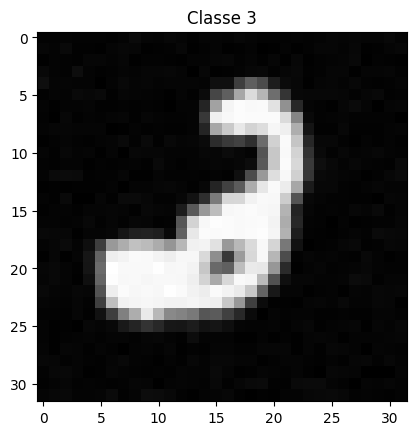

In [ ]:
imagem = ddim_sample(model, label=3)
img = imagem.squeeze().cpu().numpy()

plt.imshow(img, cmap='gray')
plt.title("Classe 3")
plt.show()

Vamos gerar 10 imagens, uma de cada classe.

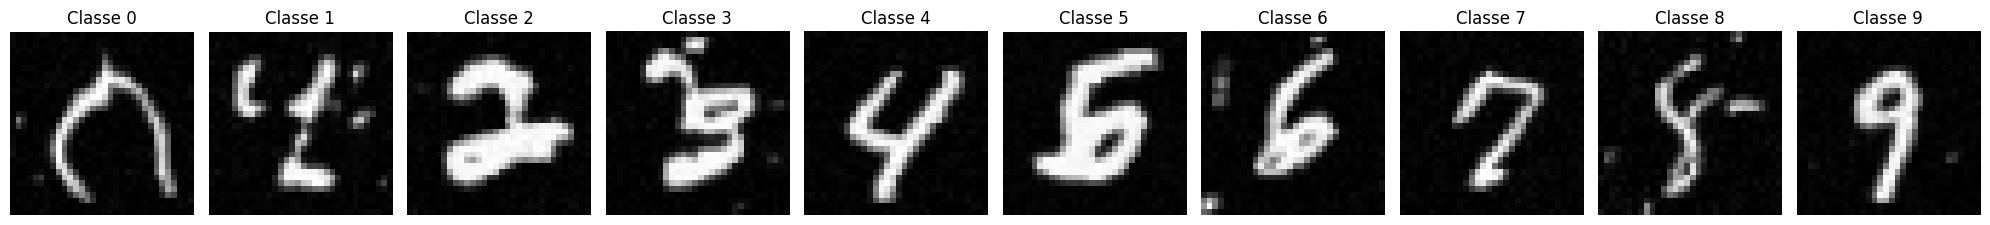

In [ ]:
# Gerar 10 amostras de classes diferentes (0 a 9)
samples = []
for i in range(10):
    # Gera a imagem para a classe i
    img = ddim_sample(model, label=i, steps=100)
    samples.append(img)

# Concatenar as imagens em um único batch para facilitar o plot
# Se ddim_sample retorna (1, 1, 32, 32), samples_tensor será (8, 1, 32, 32)
samples_tensor = torch.cat(samples, dim=0)

# Plotar as 10 imagens em uma linha
fig, axes = plt.subplots(1, 10, figsize=(20, 3))

for i in range(10):
    # squeeze() remove as dimensões de batch e canal para o imshow
    img_np = samples_tensor[i].squeeze().detach().cpu().numpy()

    # Permutar as dimensões para (height, width, channels) para matplotlib
    axes[i].imshow(img_np, cmap='gray')#.transpose(1, 2, 0))
    axes[i].set_title(f"Classe {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()